In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

#Example dataset
data = pd.DataFrame({
    'A':[10,20,30,40,50],
    'B':[5,15,25,35,45]})
print(data)
#Apply Min_max Normalization
scalar = MinMaxScaler()
normalized_data = scalar.fit_transform(data)
normalized_df = pd.DataFrame(normalized_data, columns=data.columns)
print("Normalized Data(Min-Max Scaling):")
print(normalized_data)

    A   B
0  10   5
1  20  15
2  30  25
3  40  35
4  50  45
Normalized Data(Min-Max Scaling):
[[0.   0.  ]
 [0.25 0.25]
 [0.5  0.5 ]
 [0.75 0.75]
 [1.   1.  ]]


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
scaled_df = pd.DataFrame(scaled_data, columns=data.columns)
print("Scaled Data(Standard Scaling):")
print(scaled_df)

Scaled Data(Standard Scaling):
          A         B
0 -1.414214 -1.414214
1 -0.707107 -0.707107
2  0.000000  0.000000
3  0.707107  0.707107
4  1.414214  1.414214


In [ ]:
df = pd.DataFrame({'Color':['Red','Green','Blue','Red','Green']})
#One_hot encoding
one_hot = pd.get_dummies(df, columns=['Color'])
print("One-Hot Encoded Data:")
print(one_hot)

One-Hot Encoded Data:
   Color_Blue  Color_Green  Color_Red
0       False        False       True
1       False         True      False
2        True        False      False
3       False        False       True
4       False         True      False


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
import seaborn as sns
#Load a Dataset
tips  = sns.load_dataset("tips") # or pd.read_csv("tips_csv")
print("Original Data (first 5 rows):")
print(tips.head())
#1. Normalization(Min_Max Scaling)
numeric_cols = tips.select_dtypes(include=['float64', 'int64']).columns
scaler = MinMaxScaler()
tips_normalized = tips.copy()
tips[numeric_cols] = scaler.fit_transform(tips[numeric_cols])
print("\nNormalized Data (first 5 rows):")
print(tips_normalized.head())
#2.Standardized(Z-score)
scaler_standard = StandardScaler()
tips_standardized = tips.copy()
tips_standardized[numeric_cols] = scaler.fit_transform(tips[numeric_cols])
print("\nStandardized Data (first 5 rows):")
print(tips_standardized.head())
#3. Encoding Categorical Variables
# (a) One_Hot Encoding
tips_onehot = pd.get_dummies(tips, columns=['sex', 'smoker', 'day', 'time'])
print("\nOne-Hot Encoded Data (first 5 rows):")
print(tips_onehot.head())


Original Data (first 5 rows):
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Normalized Data (first 5 rows):
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Standardized Data (first 5 rows):
   total_bill       tip     sex smoker  day    time  size
0    0.291579  0.001111  Female     No  Sun  Dinner   0.2
1    0.152283  0.073333    Male     No  Sun  Dinner   0.4
2    0.375786  0.277778    Male     No  Sun  Dinner   0.4
3    0.431713  0.25666

In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#Load dataset
tips = sns.load_dataset("tips")
numeric_cols = tips.select_dtypes(include=['float64', 'int64'])

scalar = StandardScaler()
scaled_data = scalar.fit_transform(numeric_cols)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
print("Explained variance ratio", pca.explained_variance_ratio_)
print("Principal Components (first 5 rows):")
print(pca_df.head())


Explained variance ratio [0.72627656 0.1730423 ]
Principal Components (first 5 rows):
        PC1       PC2
0 -1.348415  0.426746
1 -0.955740  1.093576
2  0.540971  0.122324
3  0.067789 -0.674616
4  1.408308  0.847661


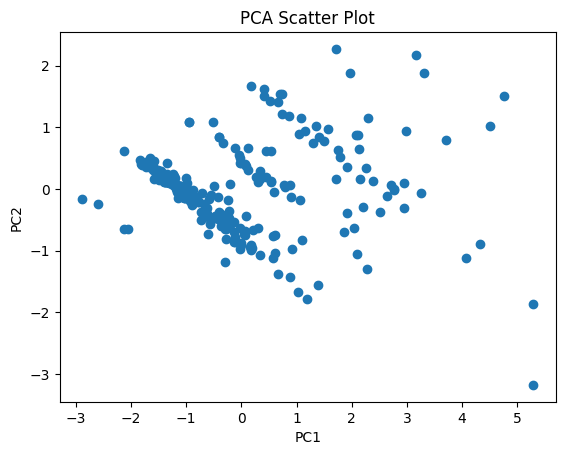

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(pca_df['PC1'], pca_df['PC2'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Scatter Plot')
plt.show()